# Two sampled gaps: RK4 and BM4Midpoint

Place **particle 50 at (0.6080, 0.5663)** in the first new image and **particle 51 at (0.4321, 0.3849)** in the second. Coordinates are normalized by periodic cell length **L**. Both methods use the same deterministic seeds, physical field, forcing phase, interval and complete-step size. No random seed is required.

Retain **particle 49 at (0.4400, 0.5805)** from the earlier study. Reuse its complete RK4 result and calculate it with BM4Midpoint. The 48 original particles of each method remain context. GC particles do not interact, so new particles can be integrated independently of that context.

This is a focused two-method seeding study, not an accuracy ranking. It omits the standard multi-method reference/timing protocol because the question is whether these specific orbits visit the two displayed gaps. No certified trajectory reference is computed.

In [1]:
from pathlib import Path
from dataclasses import asdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from diagnostics.paths import find_project_root
from diagnostics.poincare_probe import load_poincare_probe
from studies.poincare_periodicity import load_saved_poincare_section
from studies.poincare_probe import load_probe_field, probe_clearance
from studies.poincare_region_probe import RegionProbeSettings, region_probe_contract
from studies.poincare_region_results import calculate_region_probe_run, load_saved_region_panels
from visualization.poincare_probe import plot_region_sections, serve_probe_viewer, display_probe_viewer
from visualization.poincare_comparison import export_poincare_panel_comparison

PROJECT_ROOT = find_project_root(Path.cwd())
BASE = PROJECT_ROOT / "notebooks/developements/poincare_section"
STUDY = BASE / "Poincare_RK4_BM4Midpoint_regions_50_51_5000_cycles_20_steps"
SOURCES = {
    "RK4": ("Poincare_RK4_48_radiales_5000_ciclos_20_steps_local", "local_rk4_48p_5000c_20s_20260920"),
    "BM4Midpoint": ("Poincare_BM4Midpoint_48_radiales_5000_ciclos_20_steps_spot", "aws_bm4midpoint_48p_5000c_20s_20260920"),
}
RUN_DIRECTORIES = {method: STUDY / "results" / f"{method.lower()}_5000c_20s" for method in SOURCES}
ORIGINAL_RK4_PROBE = BASE / "Poincare_RK4_particle_49_gap_5000_cycles_20_steps/results/rk4_particle49_5000c_20s"
BATCH_DIRECTORIES = {
    "RK4": [ORIGINAL_RK4_PROBE, RUN_DIRECTORIES["RK4"]],
    "BM4Midpoint": [RUN_DIRECTORIES["BM4Midpoint"]],
}


## Geometry and region selection

New seeds maximize the minimum periodic distance to the **union of both methods' 240,000 saved returns each**, inside the indicated search rectangles:

| Particle | Search x/L | Search y/L | Grid | Color |
|---|---|---|---|---|
| 50 | [0.592, 0.615] | [0.553, 0.589] | 231 × 361 | violet #a000d4 |
| 51 | [0.425, 0.450] | [0.372, 0.395] | 251 × 231 | black #111111 |

The resulting seeds are held fixed between methods. `assets/selected_regions.json` records this selection and each clearance. A finite-record gap does not prove an inaccessible region, and a single orbit need not fill its area.

In [2]:
# Particle 49 retains the earlier seed; 50 and 51 address the two new images.
PROBES = {
    49: {"initial_xy_over_L": (0.4400, 0.5805), "color": "#d000d0"},
    50: {"initial_xy_over_L": (0.6080, 0.5663), "color": "#a000d4"},
    51: {"initial_xy_over_L": (0.4321, 0.3849), "color": "#111111"},
}
# Each view is (lower x/L, lower y/L, square span/L), matching the screenshots.
REGIONS = [
    {"label": "Region 1 — particle 50", "particle_id": 50, "view": (0.5802, 0.5472, 0.0614)},
    {"label": "Region 2 — particle 51", "particle_id": 51, "view": (0.4223, 0.3666, 0.0340)},
    {"label": "Original region — particle 49", "particle_id": 49, "view": (0.396, 0.529, 0.119)},
]
backgrounds = {method: load_saved_poincare_section(BASE / folder, run, tuple(range(1, 49)))
               for method, (folder, run) in SOURCES.items()}
display(pd.DataFrame([{"particle": pid, "x / L": probe["initial_xy_over_L"][0],
                      "y / L": probe["initial_xy_over_L"][1], "color": probe["color"]}
                     for pid, probe in PROBES.items()]))


,particle,x / L,y / L,color
0,49,0.4400,0.5805,#d000d0
1,50,0.6080,0.5663,#a000d4
2,51,0.4321,0.3849,#111111


,method,particle,initial clearance / L
0,RK4,50,0.008089
1,RK4,51,0.010841
2,BM4Midpoint,50,0.009849
3,BM4Midpoint,51,0.011245


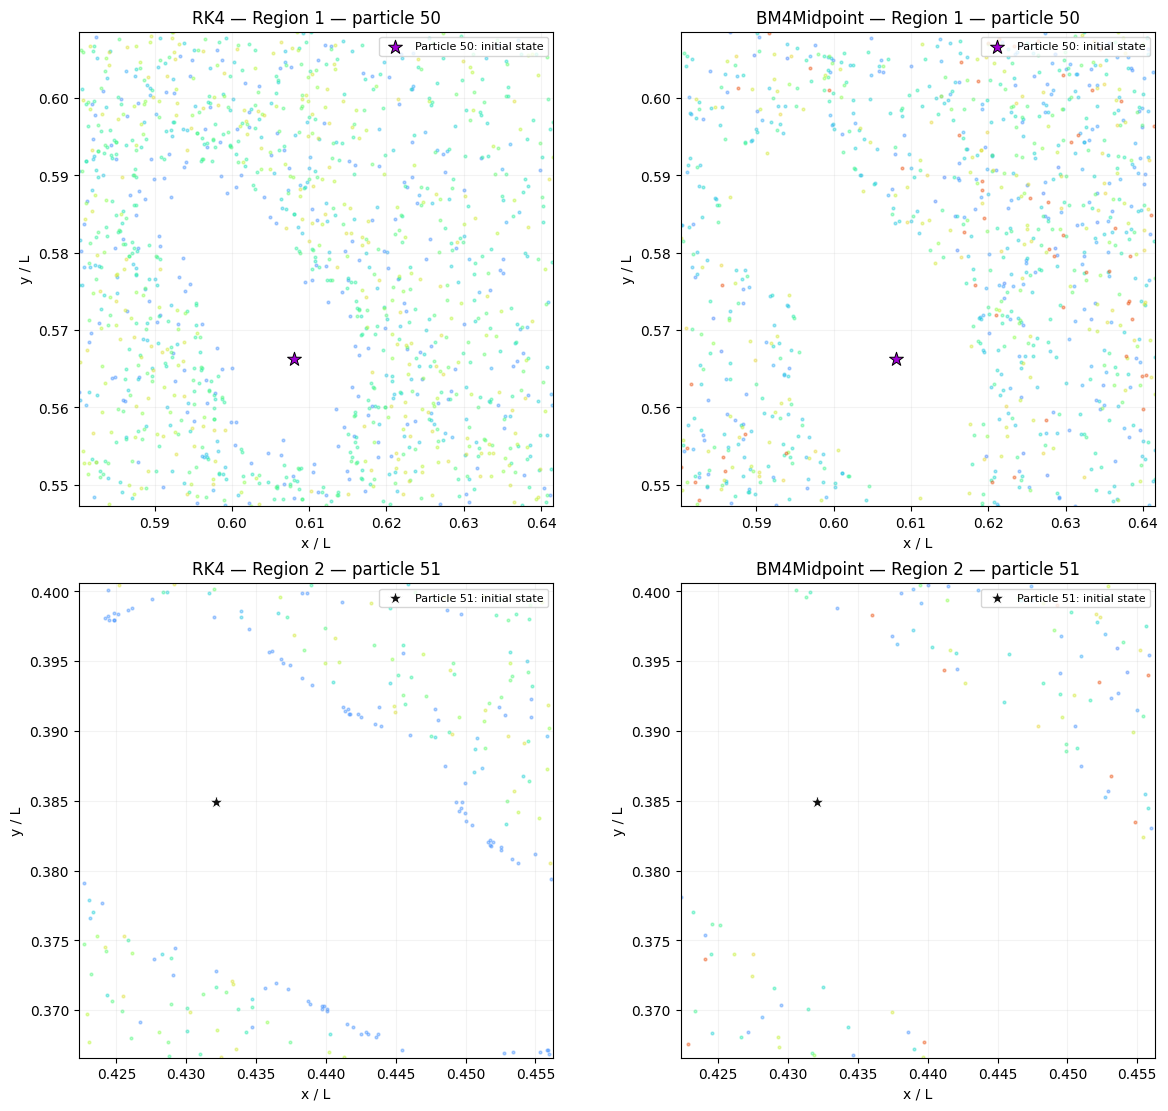

In [3]:
clearance_rows = []
for method, background in backgrounds.items():
    distances = probe_clearance(background, np.array([PROBES[pid]["initial_xy_over_L"] for pid in (50, 51)]))
    clearance_rows.extend({"method": method, "particle": pid, "initial clearance / L": value}
                          for pid, value in zip((50, 51), distances))
display(pd.DataFrame(clearance_rows))
display(plot_region_sections(backgrounds, PROBES, REGIONS[:2]))
plt.close("all")


## Explicit physical and numerical controls

The verified snapshot retains the normalized mean and first positive-frequency mode of PHI_2.h5. Its measured field uses B = 1.5 T, characteristic length 0.06 m, source selection (0, 1), cubic interpolation and unit normalized forcing period. The spatial cell has L ≈ 18.84956 in normalized physical coordinates; it is distinct from rho and the characteristic length.

**RK4** uses the original 500-step chunk schedule. **BM4Midpoint** uses the original global time grid t0 + k h, with twelve BM4 stages followed by one arithmetic mean of the two temporary copies per complete step. It has no Newton solve. Its pre-projection copy separation is retained at every step; it is not an implicit projection multiplier.

Changing controls requires a different run directory. Complete results are checksum verified and never silently overwritten. The earlier RK4 particle-49 result must remain compatible with the common settings.

In [4]:
SNAPSHOT_SHA256 = "eae45bb3f0c1ff0ee7d27985eaee6fe753dfc1cc2353e1ae75d3a66e09ed4e0d"
PHYSICAL_SETTINGS = {
    "B_tesla": 1.5,
    "characteristic_length_m": 0.06,
    "source_selection": [0, 1],
    "interpolation_order": 3,
}
RHO = 0.3
COUPLING_FREQUENCY = np.pi / 8  # BM4's temporary copies; not interparticle coupling.
CYCLES = 5000
STEPS_PER_CYCLE = 20
CHUNK_STEPS = 500  # Original context checkpoint cadence; RK4 uses this chunk schedule.
T0 = 0.0
CYCLE_DURATION = 1.0
CALCULATED_IDS = {"RK4": (50, 51), "BM4Midpoint": (49, 50, 51)}

SETTINGS = {method: RegionProbeSettings(
    method=method, particle_ids=ids,
    initial_xy_over_L=tuple(PROBES[pid]["initial_xy_over_L"] for pid in ids),
    colors=tuple(PROBES[pid]["color"] for pid in ids),
    cycles=CYCLES, steps_per_cycle=STEPS_PER_CYCLE, chunk_steps=CHUNK_STEPS,
    rho=RHO, t0=T0, cycle_duration=CYCLE_DURATION,
    coupling_frequency=COUPLING_FREQUENCY if method == "BM4Midpoint" else None,
) for method, ids in CALCULATED_IDS.items()}

potential, field_provenance = load_probe_field(
    STUDY / "assets/gc2d_snapshot.zip", expected_sha256=SNAPSHOT_SHA256,
    physical_settings=PHYSICAL_SETTINGS,
)
L = field_provenance["grid"]["period"]
np.testing.assert_allclose(potential.frequencies * CYCLE_DURATION, [1.0], rtol=0, atol=1e-14)
CONTRACTS = {method: region_probe_contract(controls, snapshot_sha256=SNAPSHOT_SHA256,
             provenance=field_provenance, background=backgrounds[method])
             for method, controls in SETTINGS.items()}
print(f"Each method: {CYCLES:,} cycles, h = {CYCLE_DURATION / STEPS_PER_CYCLE:g}, "
      f"{CYCLES * STEPS_PER_CYCLE:,} complete steps and all endpoints saved.")


Each method: 5,000 cycles, h = 0.05, 100,000 complete steps and all endpoints saved.


## RK4: calculate particles 50 and 51

The first execution integrates the new batch; subsequent executions load the matching complete result. Every step is retained in float64. The saved original particle 49 is loaded later without reintegration.

In [5]:
rk4_result = calculate_region_probe_run(potential, SETTINGS["RK4"], RUN_DIRECTORIES["RK4"],
                                        contract=CONTRACTS["RK4"])
print(f"RK4 batch shape: {rk4_result['xy'].shape}; integration: {rk4_result['runtime_seconds']:.2f} s")


RK4: loaded the complete matching probe run.
RK4 batch shape: (100001, 2, 2); integration: 225.83 s


## BM4Midpoint: calculate particles 49, 50 and 51

The three probes advance together. Their coupling frequency belongs to the method's duplicated coordinates, not to interactions between particles. The wall time below describes this batch only and should not be compared as a method benchmark against the differently sized RK4 batch.

In [6]:
midpoint_result = calculate_region_probe_run(potential, SETTINGS["BM4Midpoint"], RUN_DIRECTORIES["BM4Midpoint"],
                                             contract=CONTRACTS["BM4Midpoint"])
assert midpoint_result["method_diagnostics"]["composition_stage_count"] == 12
assert midpoint_result["method_diagnostics"]["nonlinear_unknown_dimension"] == 0
assert midpoint_result["copy_separation_norms"].shape == (CYCLES * STEPS_PER_CYCLE,)
print(f"BM4Midpoint batch shape: {midpoint_result['xy'].shape}; integration: {midpoint_result['runtime_seconds']:.2f} s")
print(f"Maximum pre-projection copy separation / L: {midpoint_result['copy_separation_norms'].max() / L:.8e}")


BM4Midpoint: loaded the complete matching probe run.
BM4Midpoint batch shape: (100001, 3, 2); integration: 1349.59 s
Maximum pre-projection copy separation / L: 8.26002860e-07


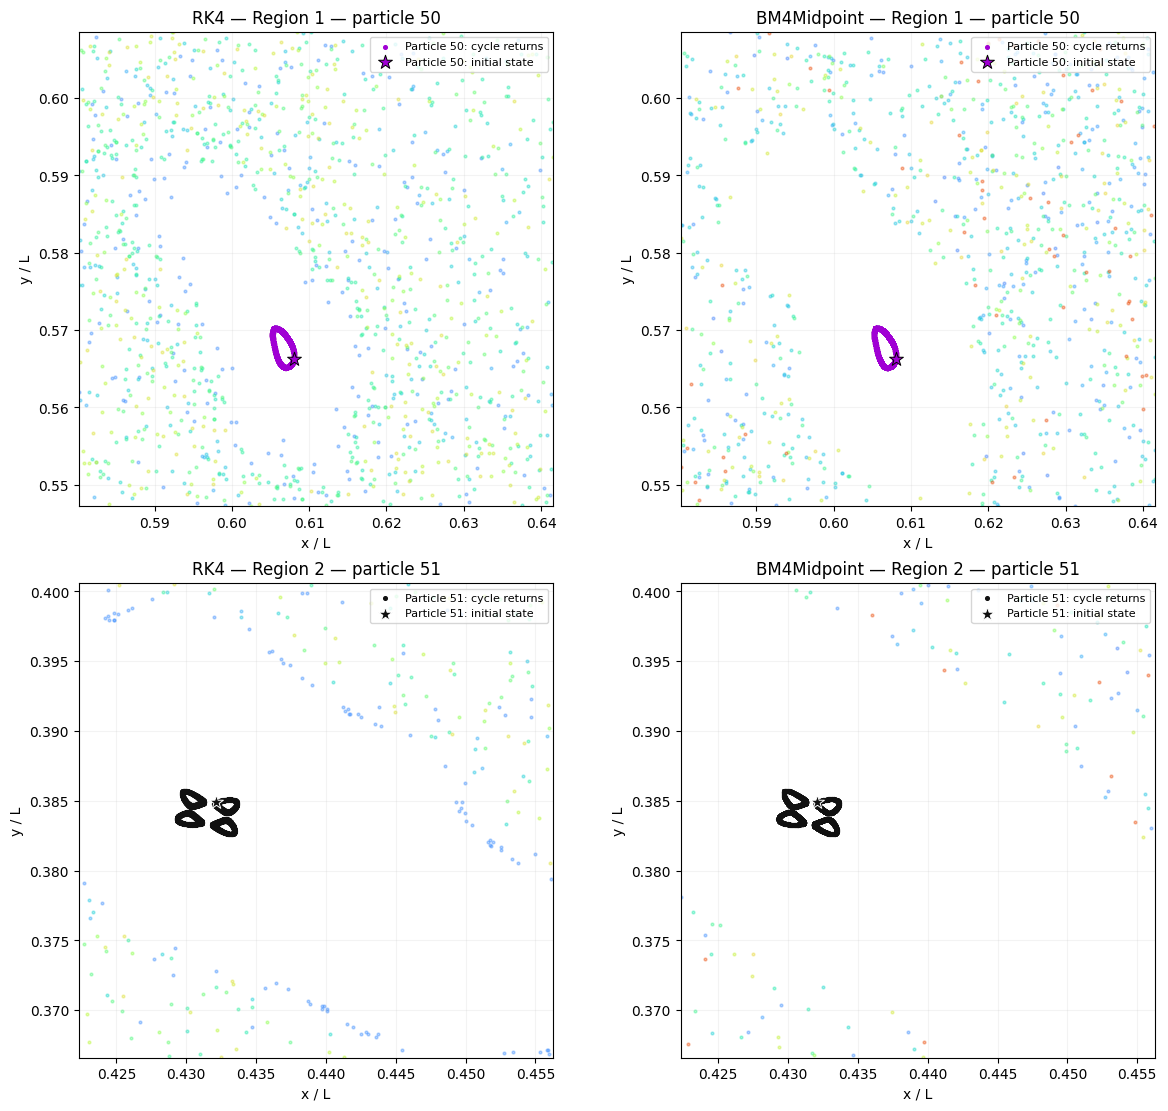

,method,particle,returns,min x/L,max x/L,min y/L,max y/L,minimum distance to context / L
0,RK4,50,5000,0.605224,0.608027,0.565150,0.570326,0.005971
1,RK4,51,5000,0.429314,0.433639,0.382607,0.385725,0.008020
2,BM4Midpoint,50,5000,0.605223,0.608028,0.565148,0.570325,0.009740
3,BM4Midpoint,51,5000,0.429310,0.433642,0.382605,0.385730,0.008579


In [7]:
panels = load_saved_region_panels(backgrounds, BATCH_DIRECTORIES)
figure = plot_region_sections(backgrounds, PROBES, REGIONS[:2], panels=panels)
figure.savefig(STUDY / "results/two_regions_comparison.png", dpi=160)
display(figure)
plt.close(figure)
summary_rows = []
for method, panel in panels.items():
    for pid in (50, 51):
        points = panel["coordinates"][:, panel["particle_ids"].index(pid)]
        summary_rows.append({"method": method, "particle": pid, "returns": len(points),
            "min x/L": points[:, 0].min(), "max x/L": points[:, 0].max(),
            "min y/L": points[:, 1].min(), "max y/L": points[:, 1].max(),
            "minimum distance to context / L": probe_clearance(backgrounds[method], points).min()})
display(pd.DataFrame(summary_rows))


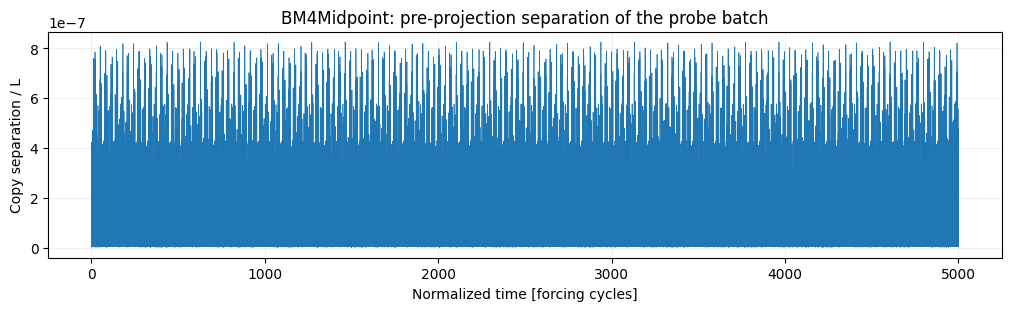

In [8]:
figure, axis = plt.subplots(figsize=(10, 3), layout="constrained")
axis.plot(midpoint_result["times"][1:], midpoint_result["copy_separation_norms"] / L, lw=.5)
axis.set(xlabel="Normalized time [forcing cycles]", ylabel="Copy separation / L",
         title="BM4Midpoint: pre-projection separation of the probe batch")
axis.grid(alpha=.2)
figure.savefig(STUDY / "results/midpoint_copy_separation.png", dpi=140)
display(figure)
plt.close(figure)


The plotted returns and bounds are computed from saved records. A closed-looking curve is not, on its own, evidence of exact periodicity or an accuracy guarantee. Open [visualizacion.ipynb](visualizacion.ipynb) to compare both methods interactively, select either new region or the original region, and filter particles and cycles.